# Gráficas de litio desde datos Fortran

Este notebook **solo grafica** a partir de archivos generados por Fortran:

- `potential_litio.dat`
- `funciones_radiales_litio.dat`
- `energias_litio_nr.dat`

No recalcula espectro ni potencial en Python.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

hartree_to_ev = 27.211386245988
base = Path('.')

pot_file = base / 'potential_litio.dat'
wf_file = base / 'funciones_radiales_litio.dat'
ene_file = base / 'energias_litio_nr.dat'

assert pot_file.exists(), f'No existe {pot_file}'
assert wf_file.exists(), f'No existe {wf_file}'
assert ene_file.exists(), f'No existe {ene_file}'

pot = np.loadtxt(pot_file, comments='#')
wf = np.loadtxt(wf_file, comments='#')

# Si energias_litio_nr.dat tiene estado,l,E(Ha),E(eV), usamos la columna 4.
energies = {}
with open(ene_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip().startswith('#') or not line.strip():
            continue
        parts = line.split()
        state = parts[0]
        e_ev = float(parts[-1])
        energies[state] = e_ev

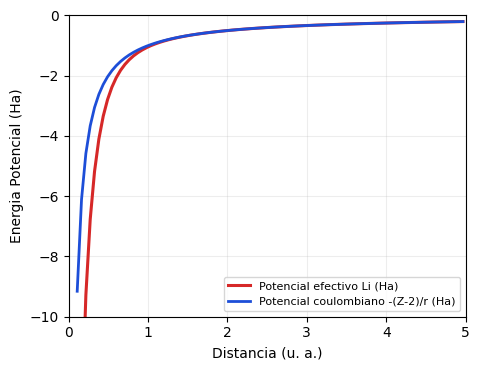

In [11]:
# Columnas: r, Vc(Ha), Veff(Ha)
r = pot[:, 0]
vc_ha = pot[:, 1]
veff_ha = pot[:, 2]

# Escala en Hartree y aspecto similar al documento
mask = (r >= 0.10) & (r <= 5.0)

fig, ax = plt.subplots(figsize=(4.9, 3.8))
ax.plot(
    r[mask], veff_ha[mask],
    lw=2.2, color='#d62828', label='Potencial efectivo Li (Ha)'
)
ax.plot(
    r[mask], vc_ha[mask],
    lw=2.0, color='#1d4ed8', label='Potencial coulombiano -(Z-2)/r (Ha)'
)
ax.set_xlim(0.0, 5.0)
ax.set_ylim(-10.0, 0.0)
ax.set_xlabel('Distancia (u. a.)')
ax.set_ylabel('Energia Potencial (Ha)')
ax.grid(alpha=0.22)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

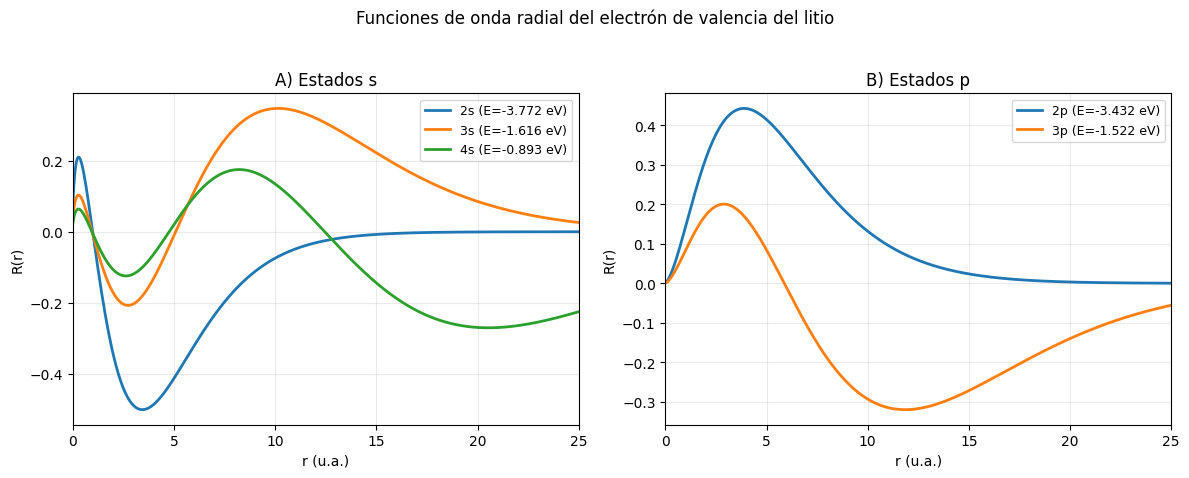

In [6]:
# Columnas: r, R_2s, R_3s, R_4s, R_2p, R_3p
rw = wf[:, 0]
r2s, r3s, r4s, r2p, r3p = wf[:, 1], wf[:, 2], wf[:, 3], wf[:, 4], wf[:, 5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

axes[0].plot(rw, r2s, lw=2.0, label=f"2s (E={energies.get('2s', np.nan):.3f} eV)")
axes[0].plot(rw, r3s, lw=2.0, label=f"3s (E={energies.get('3s', np.nan):.3f} eV)")
axes[0].plot(rw, r4s, lw=2.0, label=f"4s (E={energies.get('4s', np.nan):.3f} eV)")
axes[0].set_xlim(0.0, 25.0)
axes[0].set_xlabel('r (u.a.)')
axes[0].set_ylabel('R(r)')
axes[0].set_title('A) Estados s')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(rw, r2p, lw=2.0, label=f"2p (E={energies.get('2p', np.nan):.3f} eV)")
axes[1].plot(rw, r3p, lw=2.0, label=f"3p (E={energies.get('3p', np.nan):.3f} eV)")
axes[1].set_xlim(0.0, 25.0)
axes[1].set_xlabel('r (u.a.)')
axes[1].set_ylabel('R(r)')
axes[1].set_title('B) Estados p')
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

plt.suptitle('Funciones de onda radial del electrón de valencia del litio', y=1.03)
plt.tight_layout()
plt.show()